<a href="https://colab.research.google.com/github/Sulac1-ui/AI-Lab/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
mansi_agarwal_diabetes_path= kagglehub.dataset_download('mansiaggarwal88/diabetes-risk-prediction')

Using Colab cache for faster access to the 'diabetes-risk-prediction' dataset.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, accuracy_score, confusion_matrix, roc_auc_score

In [ ]:
import os
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/diabetes-risk-prediction/generate_dataset.py
/kaggle/input/diabetes-risk-prediction/diabetes_risk.csv


In [ ]:
import os
import pandas as pd
import kagglehub

# 1. Download dataset folder
path = kagglehub.dataset_download('mansiaggarwal88/diabetes-risk-prediction')

# 2. Read directly via pandas
df = pd.read_csv(os.path.join(path, 'diabetes_risk.csv'))

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'diabetes-risk-prediction' dataset.
First 5 records:    patient_id  age  gender       city   bmi family_history_diabetes  \
0           1   47  Female     Mumbai  26.5                     Yes   
1           2   53  Female     Mumbai  20.5                     Yes   
2           3   47    Male      Thane  31.3                      No   
3           4   41    Male  Bengaluru  22.8                      No   
4           5   57  Female  Bengaluru  16.7                      No   

  physical_activity_level       diet_type smoking_status alcohol_consumption  \
0               Sedentary      Vegetarian          Never               Never   
1                Moderate      Vegetarian          Never               Never   
2                Moderate  Non-Vegetarian        Current             Regular   
3               Sedentary  Non-Vegetarian          Never               Never   
4               Sedentary  Non-Vegetarian        Current          Occasional 

# Preprocessing, looking at the shape, column, is null or not

In [ ]:
df.shape

(15000, 19)

Data types.

In [ ]:
df.dtypes

,0
patient_id,int64
age,int64
gender,object
city,object
bmi,float64
family_history_diabetes,object
physical_activity_level,object
diet_type,object
smoking_status,object
alcohol_consumption,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

Check for the Null values.

In [ ]:
s= (df.isnull().sum()>0)

s[s].index.tolist()


['smoking_status', 'alcohol_consumption', 'income_bracket']

Impute the null features.

In [ ]:
from sklearn.impute import SimpleImputer

null_cols= s[s].index.tolist()

num_cols= df[null_cols].select_dtypes(include= ['int64', 'float64']).columns
cat_cols= df[null_cols].select_dtypes(include= ['object']).columns

print(num_cols)
print(cat_cols)


num_imputer= SimpleImputer(strategy= 'mean')
cat_imputer= SimpleImputer(strategy= 'most_frequent')

# df[num_cols]= num_imputer.fit_transform(df[num_cols])
df[cat_cols]= cat_imputer.fit_transform(df[cat_cols])

Index([], dtype='object')
Index(['smoking_status', 'alcohol_consumption', 'income_bracket'], dtype='object')


Every Values are imputed as we may need the columns inorder to predict the Person has Diabetes or not.

The columns that which are null **['smoking_status', 'alcohol_consumption', 'income_bracket']**

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicated values found.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.5,11250.25,15000.0
age,15000.0,44.333667,10.383753,18.0,38.00,45.0,52.00,80.0
bmi,15000.0,23.062260,4.046391,15.0,20.10,22.7,25.60,40.8
hours_sleep_per_night,15000.0,7.309860,1.109372,3.0,6.70,7.0,8.00,12.0
stress_level,15000.0,5.941200,2.148406,1.0,4.00,6.0,7.00,10.0
fasting_blood_sugar,15000.0,168.789933,38.365822,72.0,145.00,165.0,189.00,400.0
hba1c_level,15000.0,6.878387,0.843276,4.8,6.30,6.8,7.30,13.4
blood_pressure_systolic,15000.0,139.496200,12.660785,80.0,130.00,140.0,150.00,200.0
blood_pressure_diastolic,15000.0,86.256933,8.386529,50.0,80.00,88.0,90.00,120.0
waist_circumference_cm,15000.0,100.207933,10.760331,73.2,92.50,99.3,106.90,148.2


In [ ]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

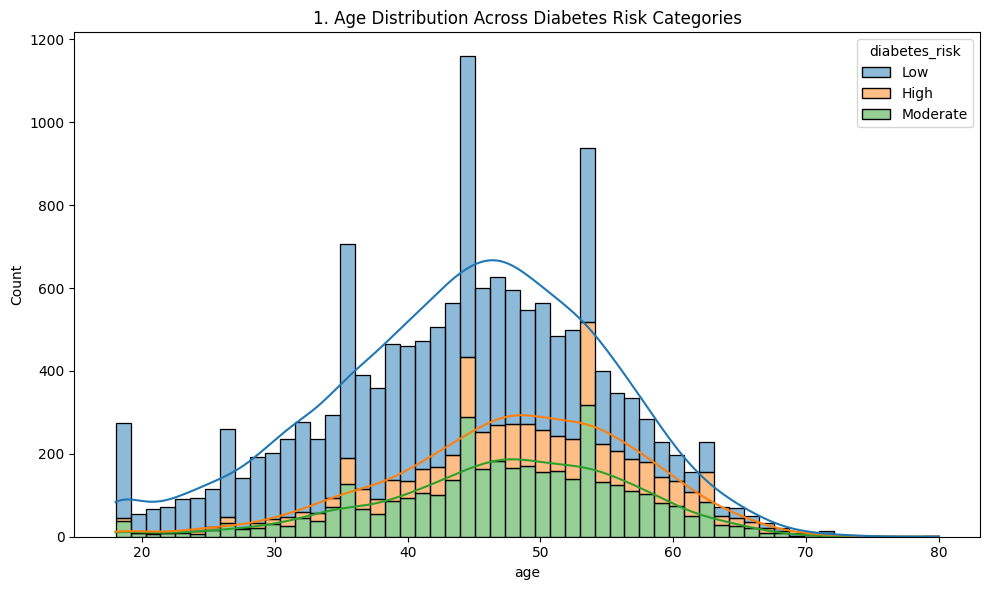

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Age Distribution Across Diabetes Risk Categories')
show_fig()
plot_no += 1

Between Age 40-60 chances of getting diabetes is moderately higher than other age group people.

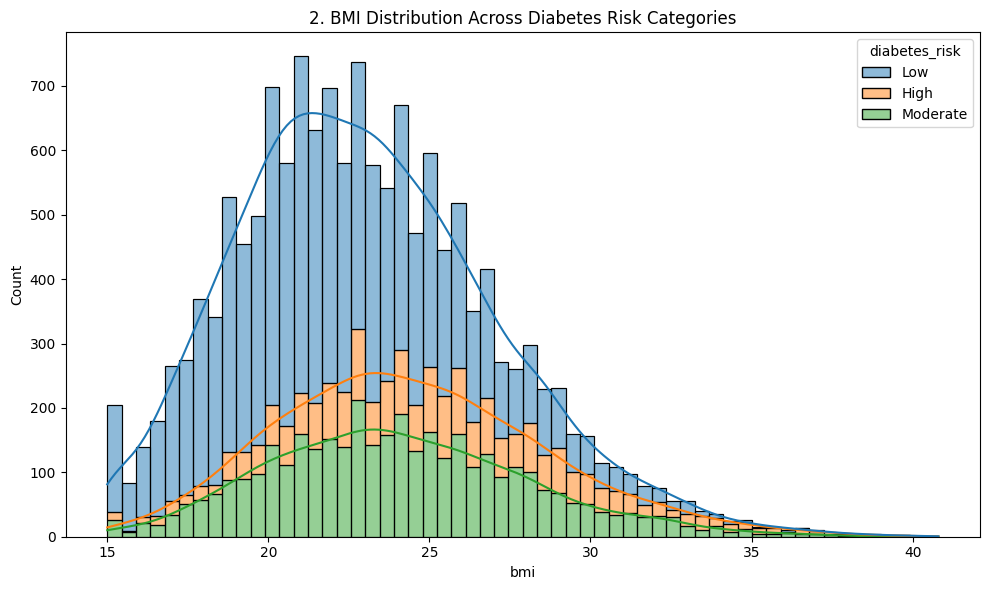

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='bmi', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. BMI Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

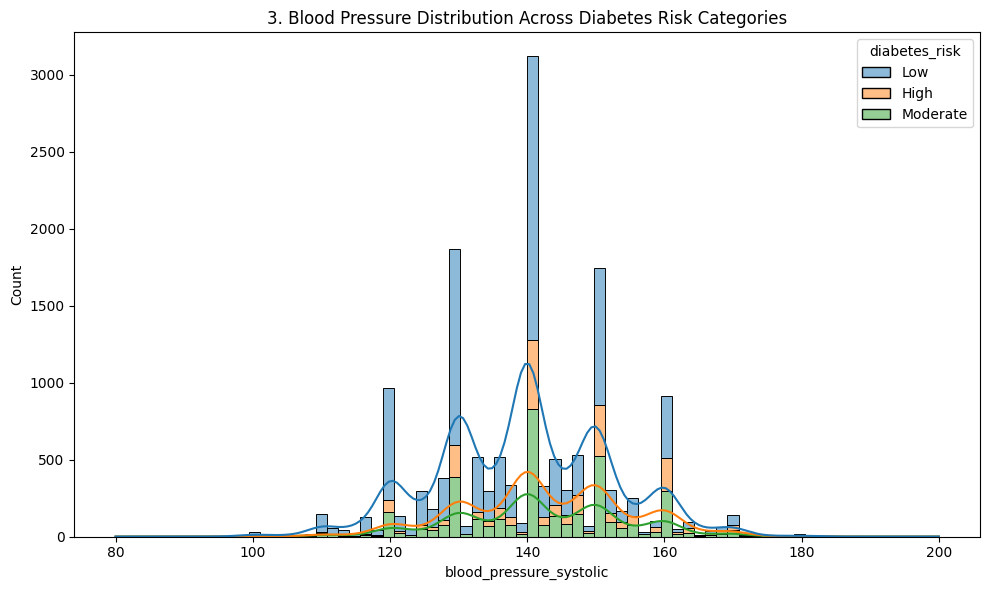

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='blood_pressure_systolic', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Blood Pressure Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

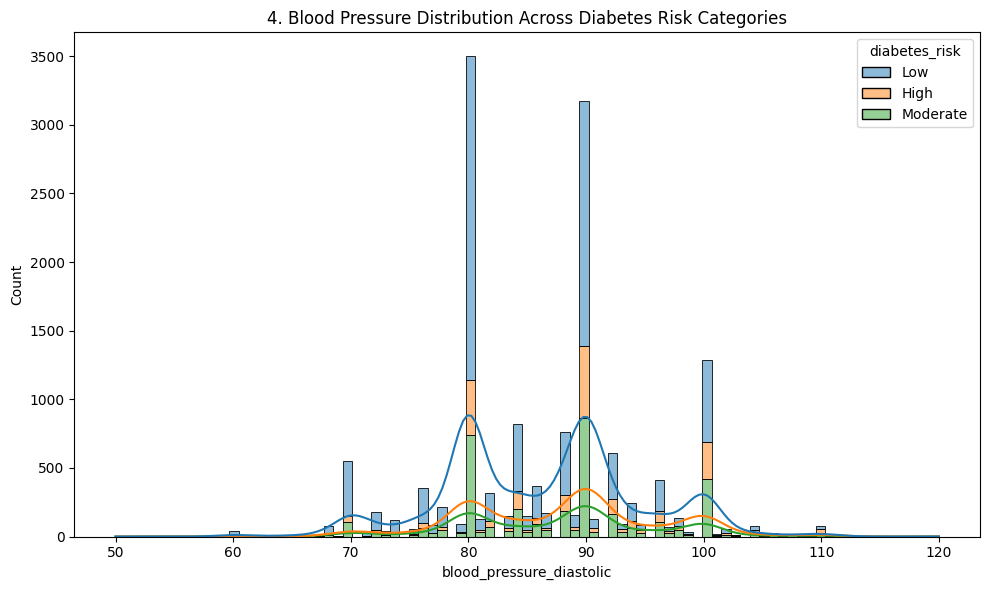

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='blood_pressure_diastolic', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Blood Pressure Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

In [ ]:
df.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket',
       'diabetes_risk'],
      dtype='object')

In [ ]:
df['diabetes_risk'].value_counts()

,count
diabetes_risk,
Low,9000
Moderate,3750
High,2250


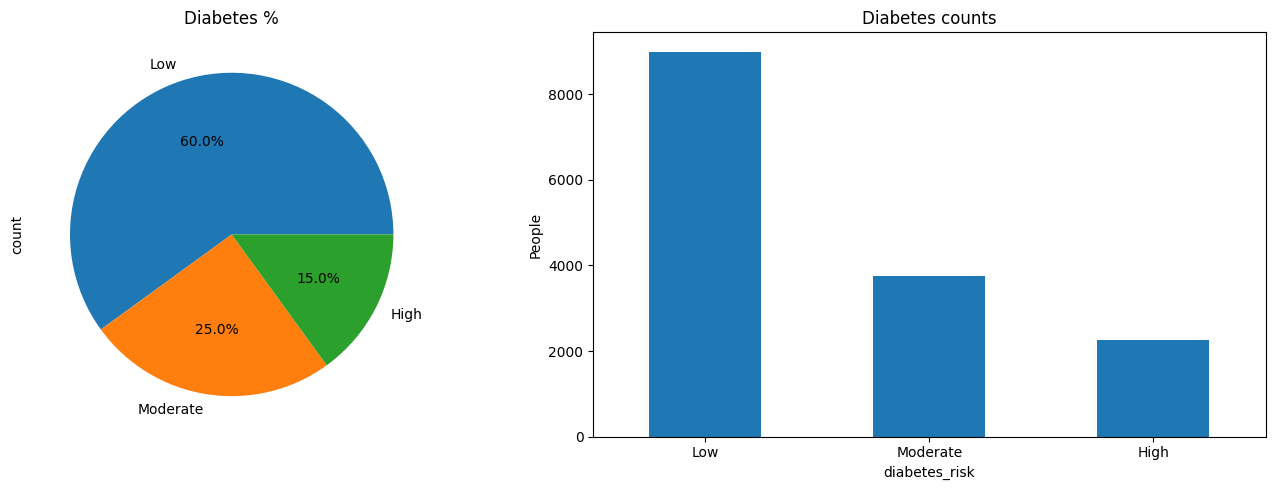

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
df['diabetes_risk'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], title='Diabetes %')
df['diabetes_risk'].value_counts().plot(kind='bar', rot=0, ax=axes[1], title='Diabetes counts')
axes[1].set_ylabel('People')
show_fig()
plot_no+=1

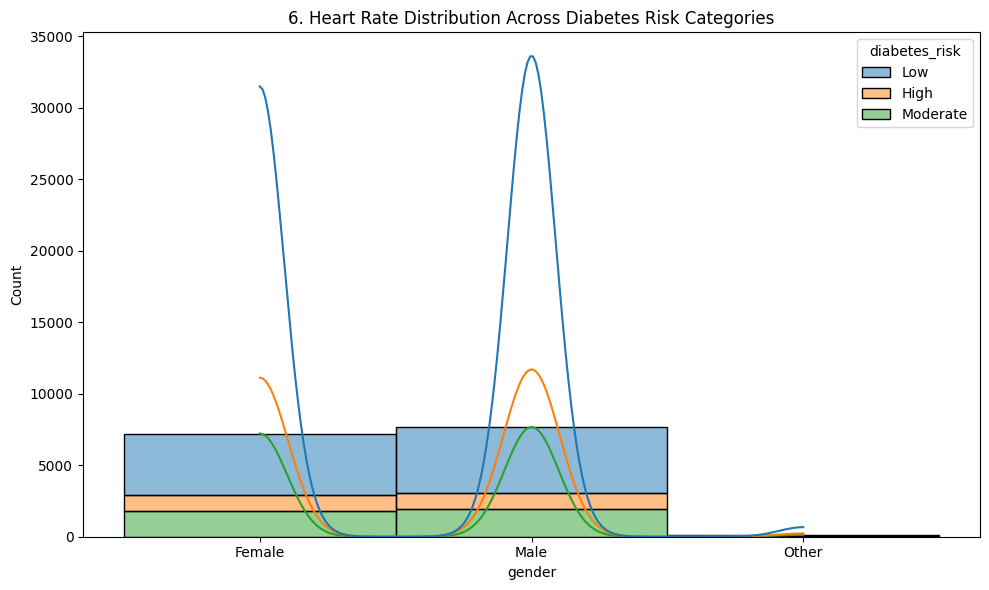

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='gender', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

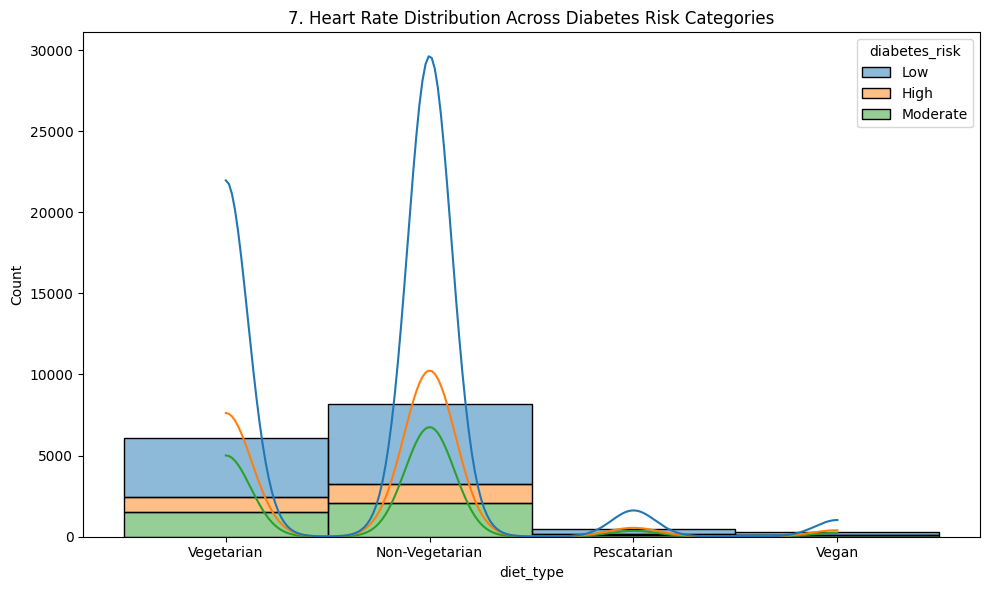

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='diet_type', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

Non_vegetarian Diet has the more number of people getting diabetes than Vegetarian, Pescatarian, and Vegan.
* highest is Non-veg, **also highest number of low diabetes is in Non_veg, however our target is to find out the diabetes so we ignore this information.**
* Second is veg
* Third Pescatarian
* Vegan

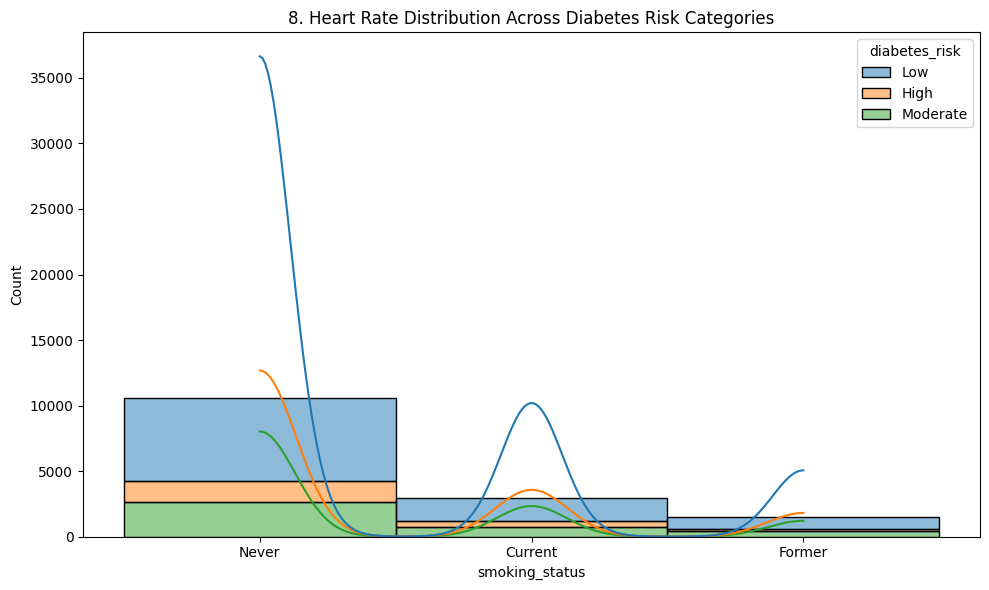

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='smoking_status', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

Interesting, those who never smoked has high number of Diabetes than Current, those who are Former smoker have less no of Diabetes.

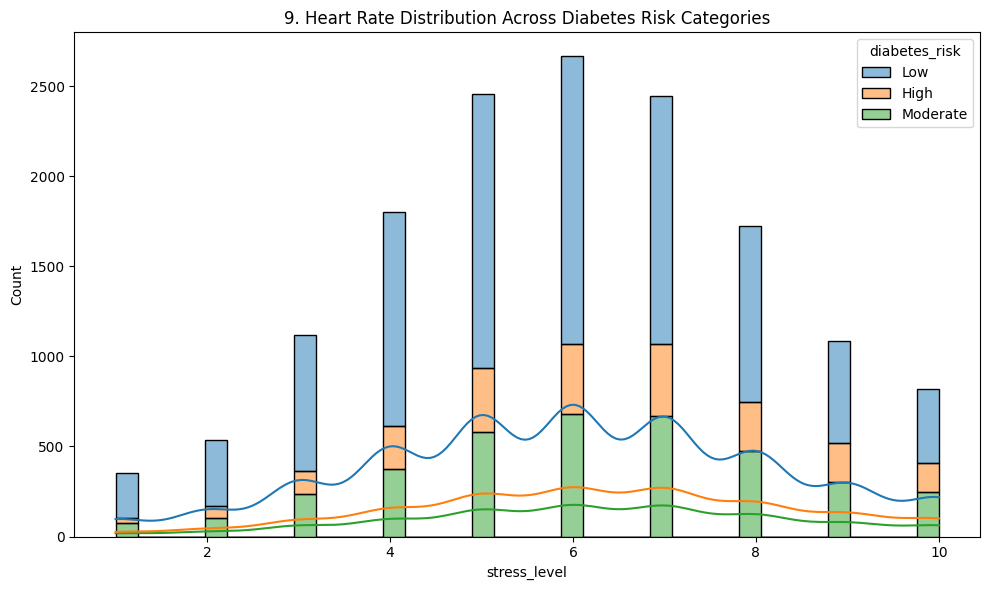

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='stress_level', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

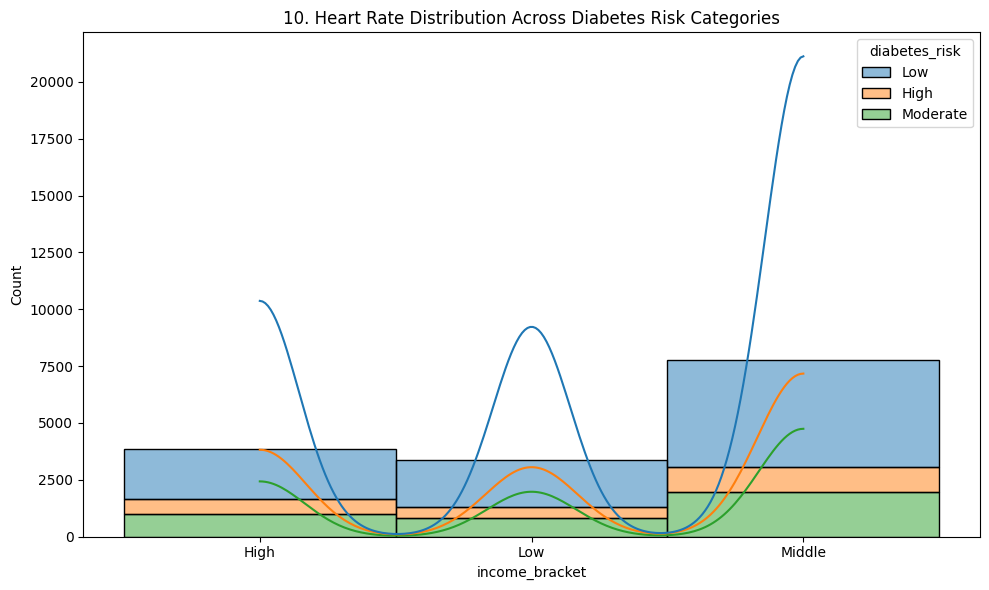

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='income_bracket', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

Those who have low income have less diabetes than High income level and Middle income level. Middle income Bracket has the highest number of Diabetes.

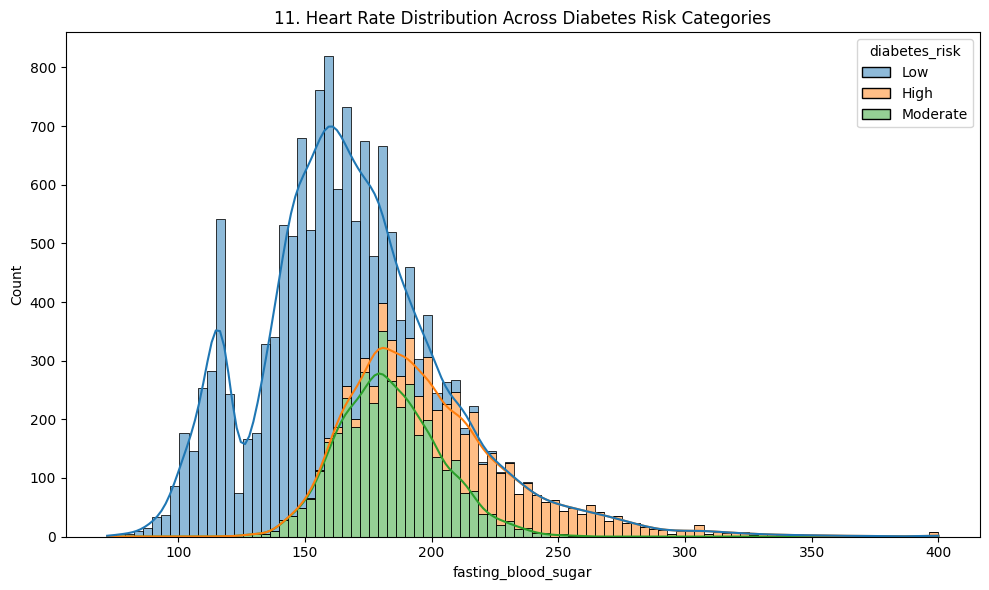

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='fasting_blood_sugar', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

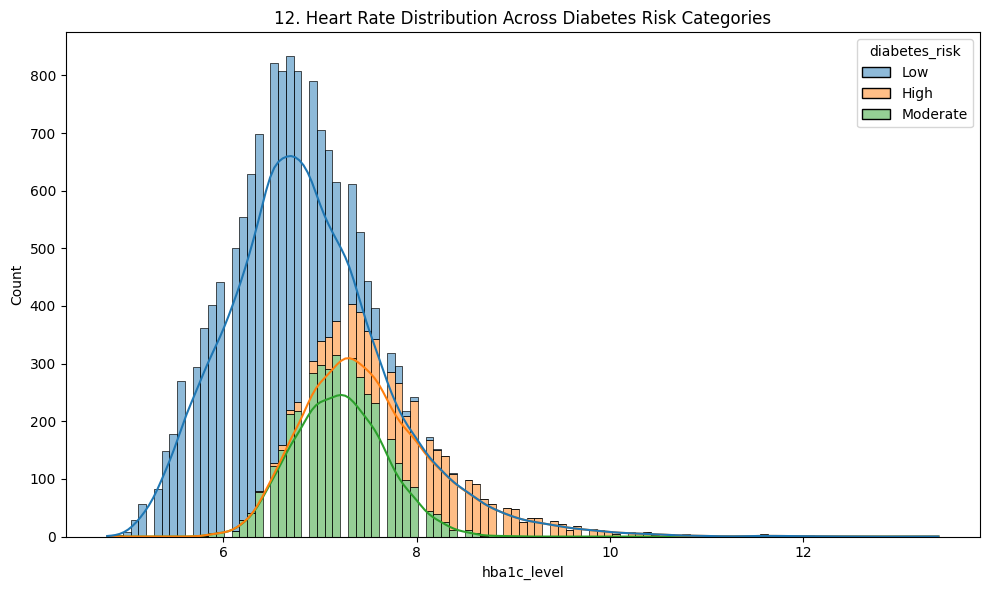

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='hba1c_level', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

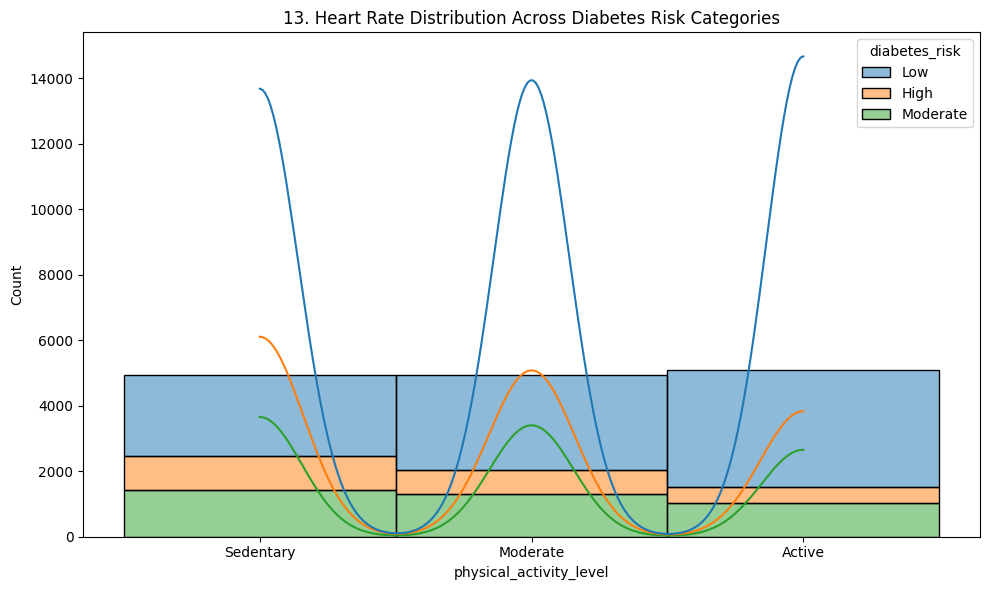

In [ ]:
fig= plt.subplots(figsize=(10,6))
sns.histplot(data=df, x='physical_activity_level', hue='diabetes_risk', kde=True, multiple='stack')
plt.title(f'{plot_no}. Heart Rate Distribution Across Diabetes Risk Categories')
show_fig()
plot_no+=1

Now we are going to check for the outliers for that we are going to plot the Boxplot, probably Violin Plot.

In [ ]:
num_col= df.select_dtypes(include= ['int64', 'float64']).columns

# for i in num_col:
#   print("--", i)
# len(num_col)
num_col= list(num_col)
del(num_col[0])
num_col

['age',
 'bmi',
 'hours_sleep_per_night',
 'stress_level',
 'fasting_blood_sugar',
 'hba1c_level',
 'blood_pressure_systolic',
 'blood_pressure_diastolic',
 'waist_circumference_cm']

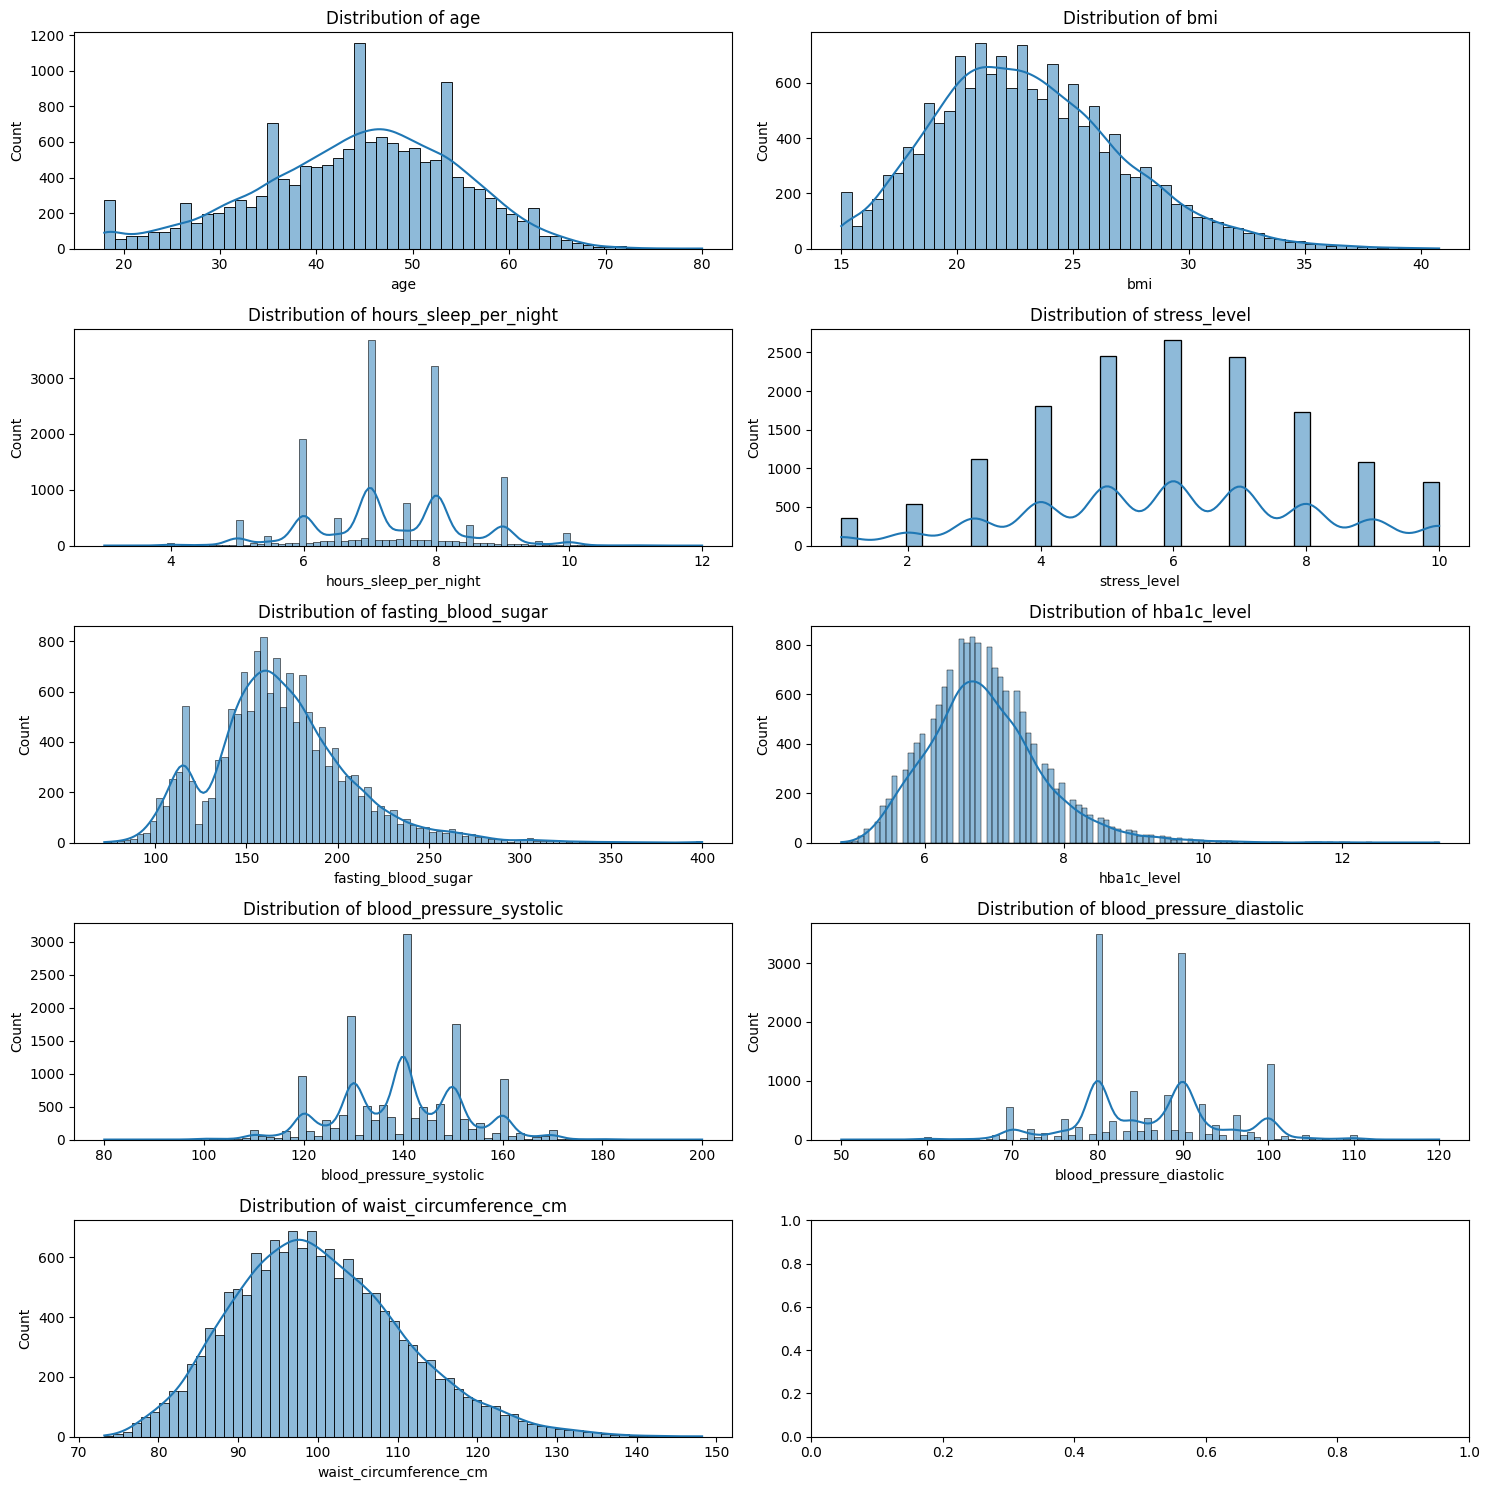

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(15, 15))

num_cols = list(num_col)
for i, col in enumerate(num_cols):
  r, c = i // 2, i % 2
  sns.histplot(df[col].dropna(), kde=True, ax=axes[r,c])
  axes[r,c].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

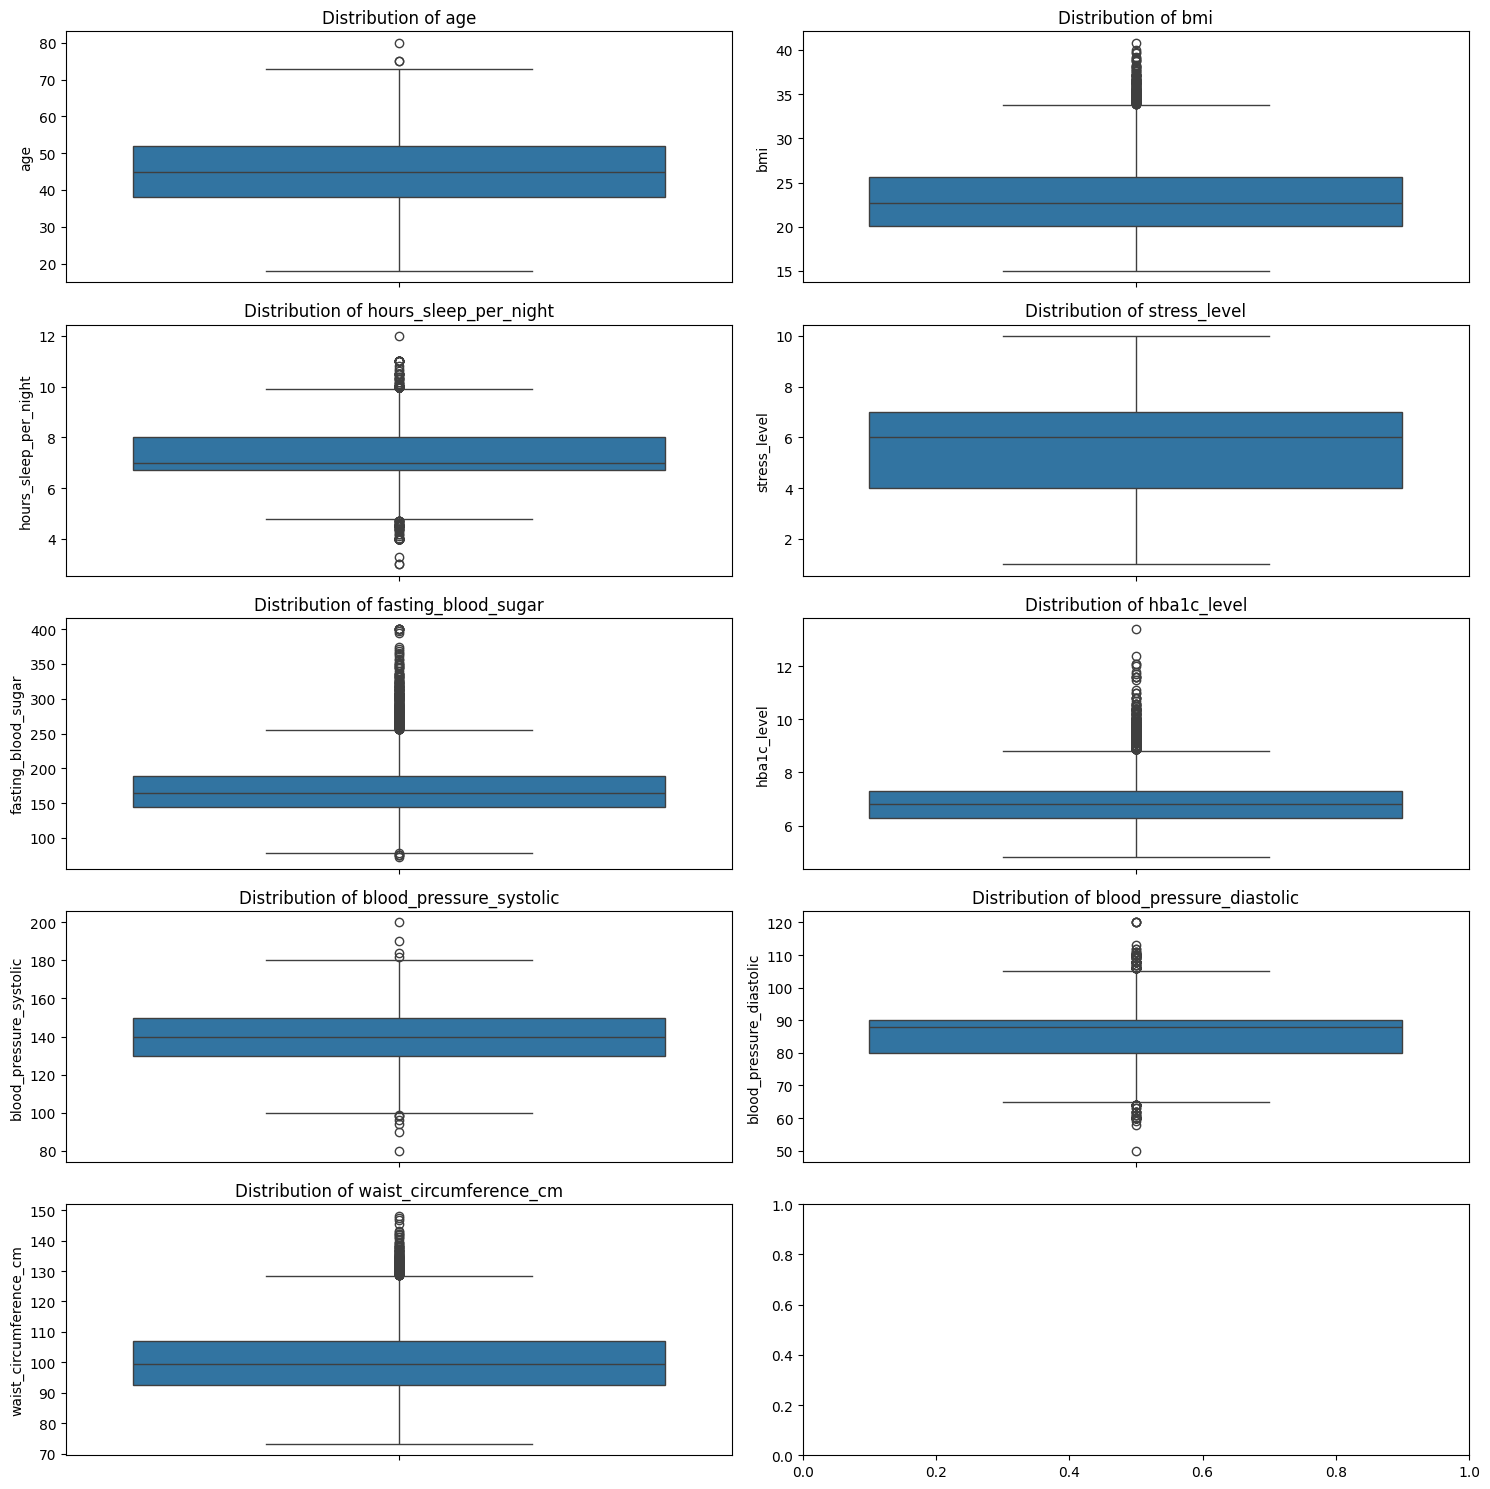

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(15, 15))

num_cols = list(num_col)
for i, col in enumerate(num_cols):
  r, c = i // 2, i % 2

  sns.boxplot(df[col].dropna(), ax=axes[r,c])
  axes[r,c].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

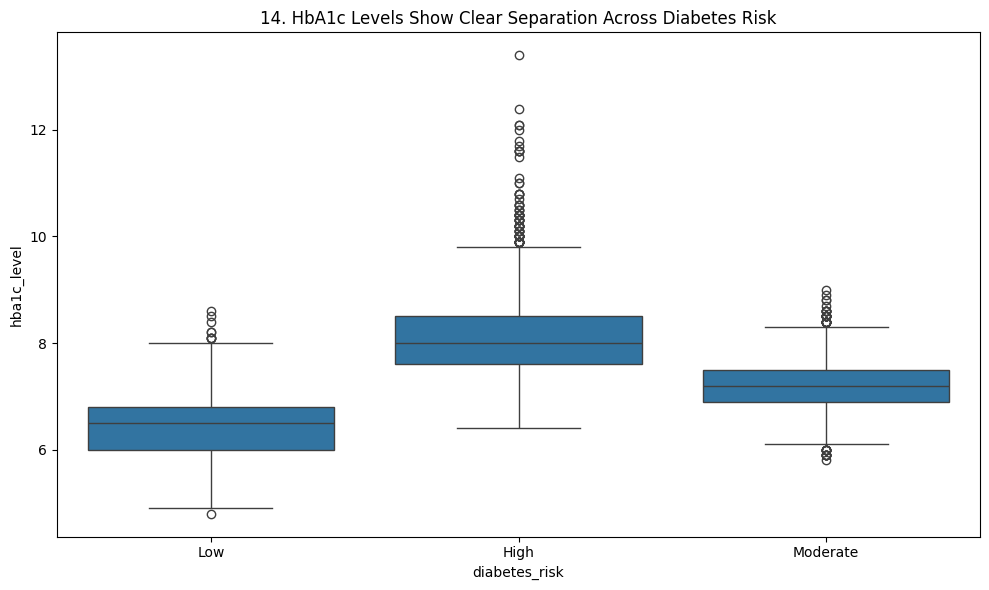

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='diabetes_risk', y='hba1c_level')
plt.title(f'{plot_no}. HbA1c Levels Show Clear Separation Across Diabetes Risk')
show_fig()
plot_no += 1

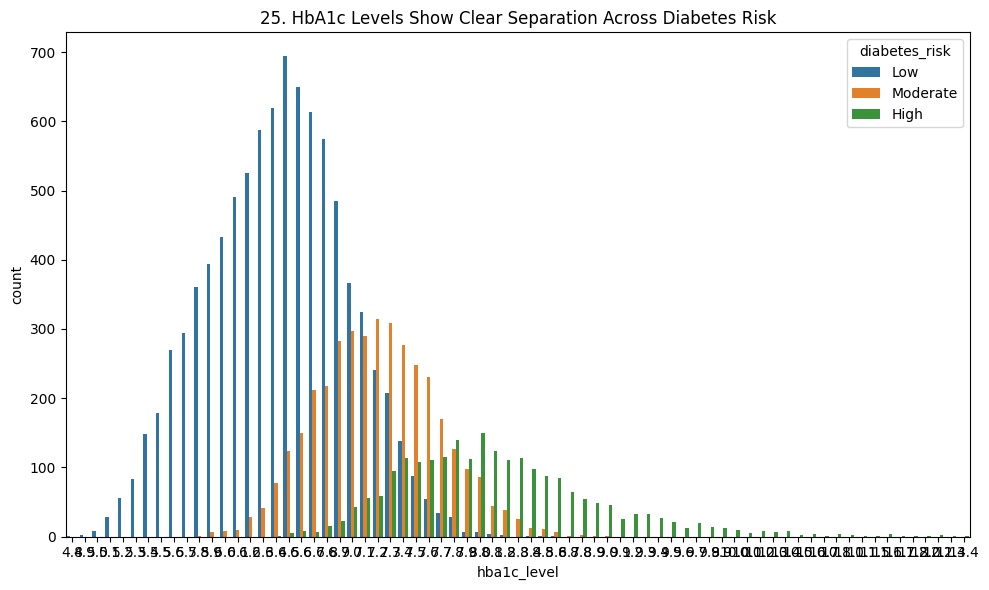

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hba1c_level', hue= 'diabetes_risk')
plt.title(f'{plot_no}. HbA1c Levels Show Clear Separation Across Diabetes Risk')
show_fig()
plot_no += 1

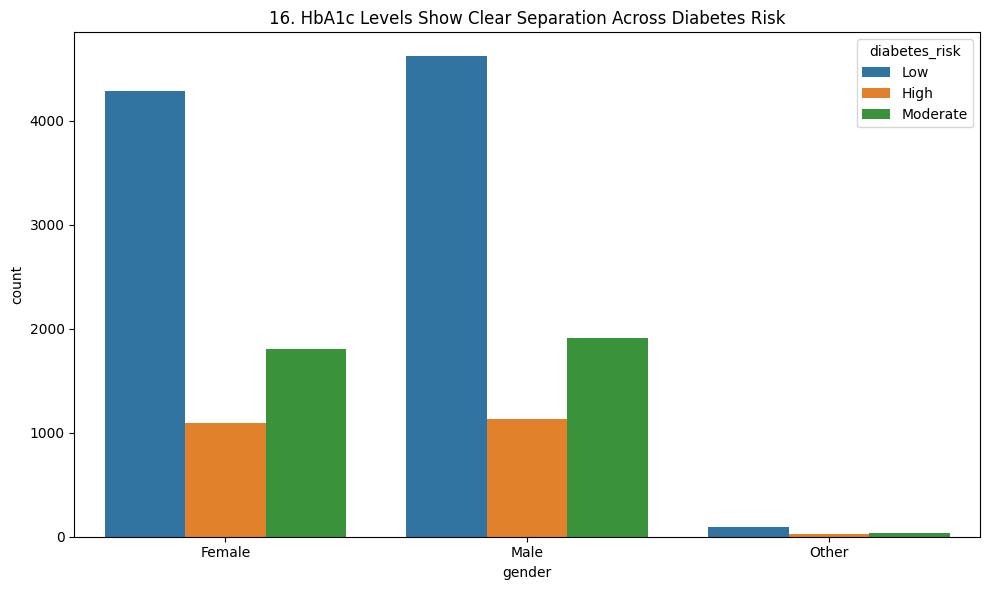

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender', hue='diabetes_risk')
plt.title(f'{plot_no}. HbA1c Levels Show Clear Separation Across Diabetes Risk')
show_fig()
plot_no += 1

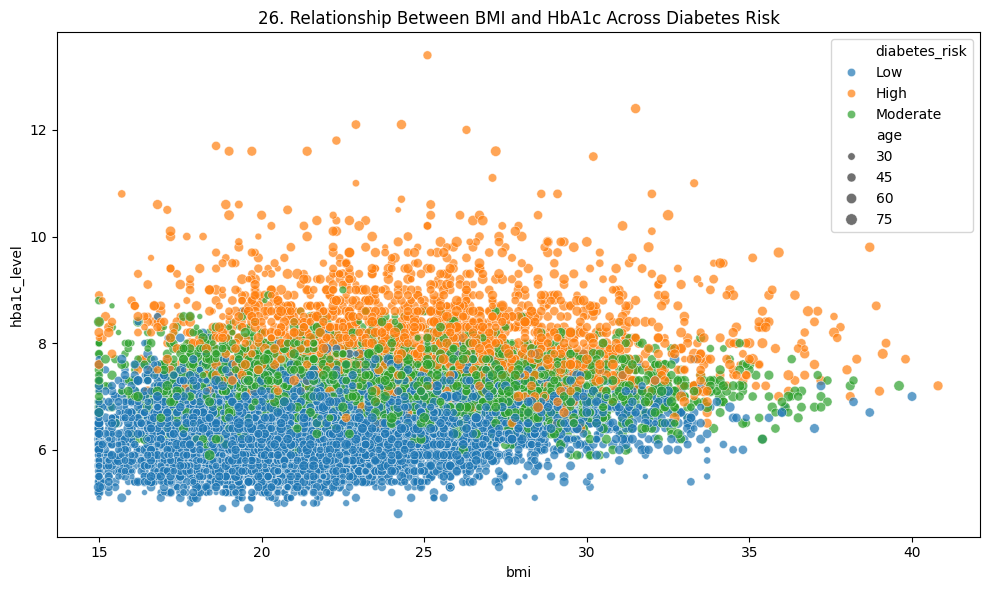

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bmi', y='hba1c_level', hue='diabetes_risk', size='age', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between BMI and HbA1c Across Diabetes Risk')
show_fig()
plot_no += 1

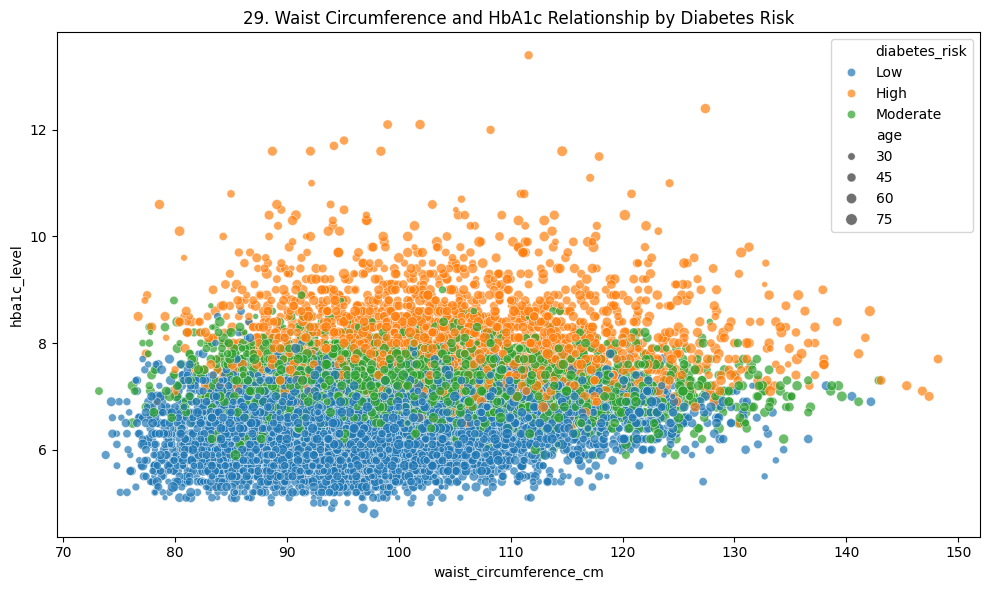

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='waist_circumference_cm', y='hba1c_level', hue='diabetes_risk', size= 'age', alpha=0.7)
#size= 'age', markers size increase or decrease with the age.
plt.title(f'{plot_no}. Waist Circumference and HbA1c Relationship by Diabetes Risk')
show_fig()
plot_no += 1

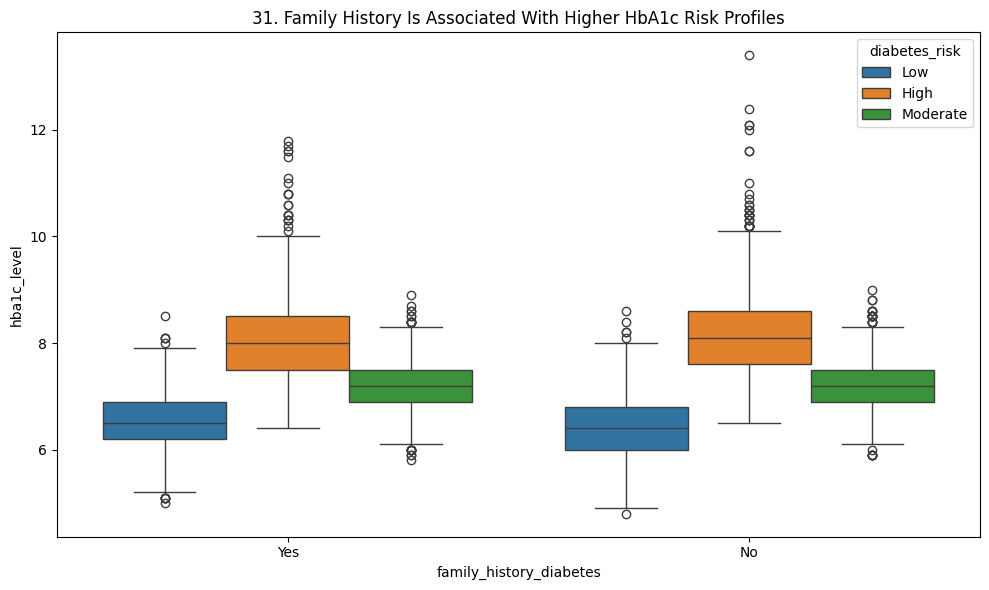

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='family_history_diabetes', y='hba1c_level', hue='diabetes_risk')
plt.title(f'{plot_no}. Family History Is Associated With Higher HbA1c Risk Profiles')
show_fig()
plot_no += 1


* interesting those who have Family diabetes got high diabetes, however those who don't got from their family is even more than those who have hereditery.

# Outlier detection using IQR and Z-score

In [ ]:
import statistics
from scipy import stats

In [ ]:
outlier_summary={}

for col in num_col:
  series= df[col].dropna()
  q1= series.quantile(0.25)
  q3= series.quantile(0.75)
  iqr= q3-q1

  lower_bound= q1-1.5*iqr
  upper_bound= q3+1.5*iqr

  outliers= series[(series<lower_bound) | (series>upper_bound)]
  zscores = np.abs(stats.zscore(series))
  z_outliers = series[zscores > 3]

  outlier_summary[col]={
      'Iqr_outlier':len(outliers),
      # 'outliers':outliers,
      'Zscore_outlier':len(z_outliers)
  }


outlier_summary

{'age': {'Iqr_outlier': 3, 'Zscore_outlier': 1},
 'bmi': {'Iqr_outlier': 153, 'Zscore_outlier': 82},
 'hours_sleep_per_night': {'Iqr_outlier': 360, 'Zscore_outlier': 22},
 'stress_level': {'Iqr_outlier': 0, 'Zscore_outlier': 0},
 'fasting_blood_sugar': {'Iqr_outlier': 432, 'Zscore_outlier': 151},
 'hba1c_level': {'Iqr_outlier': 355, 'Zscore_outlier': 142},
 'blood_pressure_systolic': {'Iqr_outlier': 11, 'Zscore_outlier': 56},
 'blood_pressure_diastolic': {'Iqr_outlier': 213, 'Zscore_outlier': 57},
 'waist_circumference_cm': {'Iqr_outlier': 167, 'Zscore_outlier': 80}}

In [ ]:
# Filter out literal physiological impossibilities (keep extreme clinical disease markers)
valid_mask= (
    (df['age'].between(0,120))&
    (df['bmi'].between(10, 100)) &
    (df['fasting_blood_sugar'].between(30, 800)) &
    (df['hba1c_level'].between(3.0, 25.0))
)

In [ ]:
clean_df= df[valid_mask]

In [ ]:
clean_df.shape

(15000, 19)

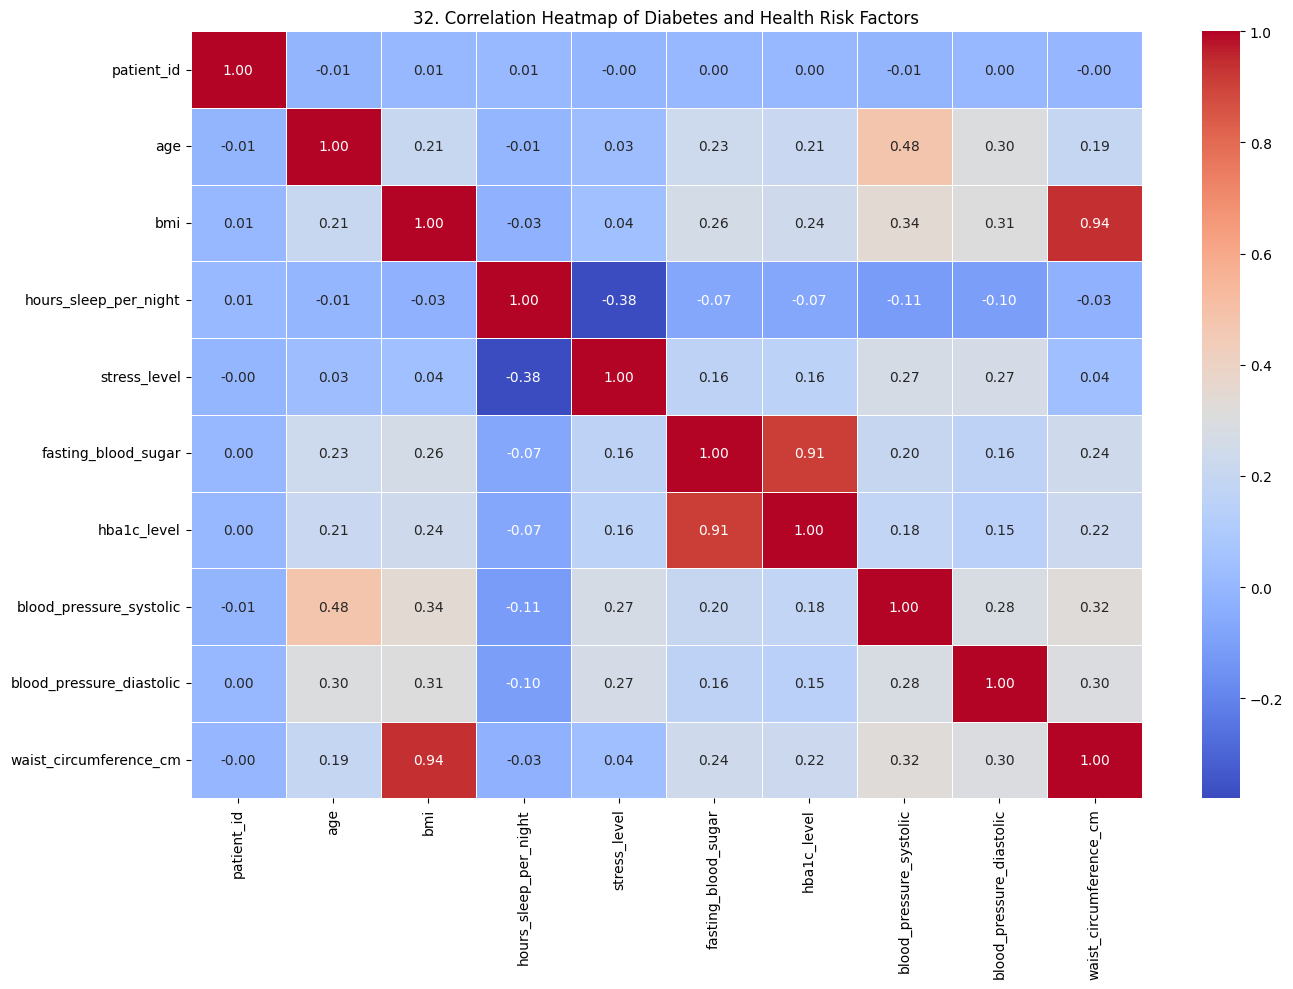

In [ ]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Diabetes and Health Risk Factors')
show_fig()
plot_no += 1


# **Model Training**

In [ ]:
X = clean_df.drop(columns=['patient_id', 'diabetes_risk'])
y = clean_df['diabetes_risk']

# **Convert categorical features into numerical features**

In [ ]:
# X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain, xtest, ytrain, ytest= train_test_split(X, y, random_state= 42, test_size=0.2 , stratify=y)

In [ ]:
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((12000, 17), (3000, 17), (12000,), (3000,))

In [ ]:
scaler= StandardScaler()
scaler.fit(xtrain)
xtrain= scaler.transform(xtrain)
xtest= scaler.transform(xtest)

ValueError: could not convert string to float: 'Female'

In [ ]:
lr= LogisticRegression(max_iter= 1000, random_state= 42)
lr.fit(xtrain, ytrain)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
ypred= lr.predict(xtest)

In [ ]:
accuracy = accuracy_score(ytest, ypred)
print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.7936666666666666
Model Accuracy (%): 79.36666666666666


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print('-- Classification report--')
print(classification_report(ytest, ypred))

-- Classification report--
              precision    recall  f1-score   support

        High       0.82      0.72      0.76       450
         Low       0.86      0.91      0.88      1800
    Moderate       0.60      0.56      0.58       750

    accuracy                           0.79      3000
   macro avg       0.76      0.73      0.74      3000
weighted avg       0.79      0.79      0.79      3000



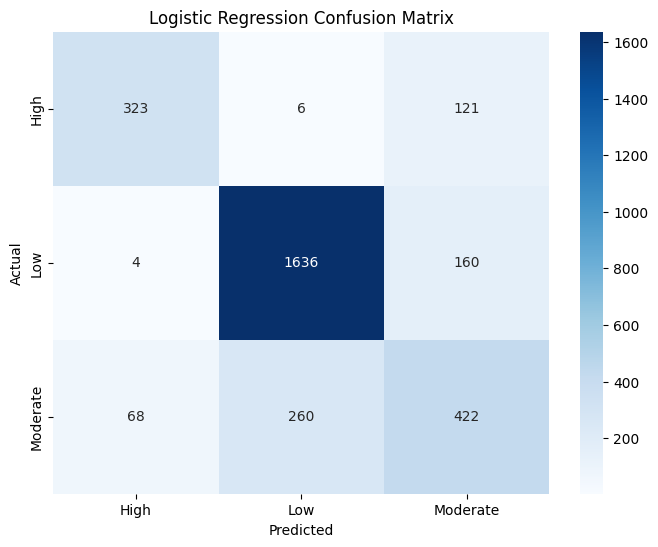

In [ ]:
cm = confusion_matrix(ytest, ypred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr.classes_,
    yticklabels=lr.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
numeric_feature= X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_feature= X.select_dtypes(include=['object']).columns.tolist()

In [ ]:
# del(numeric_feature[0])
print(categorical_feature)
print(numeric_feature)

['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']
['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']


# One-Hot encoding pipeline (with imputation and scaling)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
numeric_transformer= Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy= 'median')),
        ('scaler', StandardScaler())
    ]
)
onehot_transformer= Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy= 'most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False))
    ]
)
preprocessor_onehot= ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_feature),
        ('cat', onehot_transformer, categorical_feature)
    ]
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
baseline_lr = Pipeline(steps=[
    ('pre', preprocessor_onehot),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


baseline_dt = Pipeline(steps=[
    ('pre', preprocessor_onehot),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

In [ ]:
baseline_dt.fit(xtrain, ytrain)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'hours_sleep_per_night',
                                                   'stress_level',
                                                   'fasting_blood_sugar',
                                                   'hba1c_level',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'waist_circumference_cm']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'city',
                                                   'family_history_diabetes',
                                                   'physical_activity_level',
                                                   'diet_type',
                                                   'smoking_status',
                                                   'alcohol_consumption',
                                                   'income_bracket'])])),
                ('clf',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
ypred= baseline_dt.predict(xtest)

In [ ]:
accuracy = accuracy_score(ytest, ypred)
print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.7043333333333334
Model Accuracy (%): 70.43333333333334


In [ ]:
from sklearn.metrics import average_precision_score, average_precision_score,precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [ ]:
baseline_lr.fit(xtrain, ytrain)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'hours_sleep_per_night',
                                                   'stress_level',
                                                   'fasting_blood_sugar',
                                                   'hba1c_level',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'waist_circumference_cm']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'city',
                                                   'family_history_diabetes',
                                                   'physical_activity_level',
                                                   'diet_type',
                                                   'smoking_status',
                                                   'alcohol_consumption',
                                                   'income_bracket'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
confusion_matrix(ytest, ypred)

array([[ 304,   27,  119],
       [  32, 1485,  283],
       [ 137,  289,  324]])

# **Testing Other models.**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.5 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import time
import warnings
from sklearn.model_selection import cross_val_score
import time;
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)

In [ ]:
X_train = pd.DataFrame(xtrain)
X_test = pd.DataFrame(xtest)
y_train = pd.DataFrame(ytrain)
y_test = pd.DataFrame(ytest)

In [ ]:
x= pd.concat([X_train, X_test], axis=0)
y= pd.concat([y_train, y_test], axis=0)

In [ ]:
y

,diabetes_risk
7666,Low
136,Low
5808,Low
9042,Low
13895,Moderate
...,...
4430,Low
4511,High
1068,High
14655,Low


In [ ]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
y = le.fit_transform(y)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
ordinal_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])


preprocessor_ordinal = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_feature),
        ('cat', ordinal_transformer, categorical_feature)
], remainder='drop')

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [ ]:
rf_pipeline= Pipeline(
    steps=[
        ('pre', preprocessor_ordinal),
        ('clf', RandomForestClassifier(random_state=42))
    ]
)

rf_param_dist = {
    'clf__n_estimators': [100, 300, 600],
    'clf__max_depth': [None, 6, 12, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__max_features': ['sqrt', 'log2', 0.3, 0.6]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_search = RandomizedSearchCV(rf_pipeline, rf_param_dist, n_iter=20, scoring='roc_auc', cv=cv, verbose=1, n_jobs=-1, random_state=42)
rf_search.fit(X_train, y_train)

print('Best RF params:', rf_search.best_params_)
rf_best = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best RF params: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__max_features': 'log2', 'clf__max_depth': 20}


In [ ]:
xgb = XGBClassifier(n_jobs = -1)

In [ ]:
start = time.time()

# Replace object columns with ordinal integers safely or use ColumnTransformer
x_ord = x.copy()
cat_cols = x_ord.select_dtypes(include=['object']).columns
for col in cat_cols:
    x_ord[col] = x_ord[col].astype(str).astype('category').cat.codes

xgb_standard = XGBClassifier(objective='multi:softprob', num_class=3, random_state=42)
print(cross_val_score(xgb_standard, x_ord, y, cv=10, scoring='accuracy').mean()*100)

time.time()-start

77.98


25.990166664123535

In [ ]:
le= LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
xgb.fit(X_train, y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gender: object, city: object, family_history_diabetes: object, physical_activity_level: object, diet_type: object, smoking_status: object, alcohol_consumption: object, income_bracket: object

In [ ]:
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Xtreme Gradient Boosting Accuracy:", accuracy)
print("Xtreme Gradient Boosting Accuracy (%):", accuracy * 100)

NotFittedError: need to call fit or load_model beforehand